## Purpose
This notebook will identify last 3 months best perfomer

In [188]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

In [189]:
config = configparser.ConfigParser()
config.read(os.path.join(os.path.dirname(os.path.abspath("__file__")), '../conf/config.ini'))
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [190]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [191]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [192]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 180)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter(col("Symbol") == 'AAPL')
# Show the result
filtered_df.printSchema()
filtered_df.show(2, truncate=False)

root
 |-- Date: date (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- price_change: double (nullable = true)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change      |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|2024-08-14|220.57000732421875|223.02999877929688|219.6999969482422 |221.72000122070312|221.72000122070312|41960600|AAPL  |0.4499969482421875|
|2024-08-14|191.0             |193.35000610351562|190.47000122070312|193.0         

In [193]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

def analyze_stock_data(df: DataFrame):
    """
    Analyze stock market data and calculate key technical indicators using Spark
    
    Parameters:
    df (DataFrame): Spark DataFrame with columns Date, Open, High, Low, Close, Volume, symbol
    
    Returns:
    DataFrame: Original data with additional technical indicators
    dict: Summary statistics
    """
    # Convert string columns to double
    numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    analysis = df
    for col in numeric_columns:
        analysis = analysis.withColumn(col, F.col(col).cast(DoubleType()))
    
    # Calculate daily trading range
    analysis = analysis.withColumn('daily_range', F.col('High') - F.col('Low'))
    
    # Create window specs
    window_20 = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-19, 0)
    window_50 = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-49, 0)
    
    # Calculate moving averages
    analysis = analysis.withColumn('MA_20', F.avg('Close').over(window_20))
    analysis = analysis.withColumn('MA_50', F.avg('Close').over(window_50))
    
    # Calculate volatility (20-day rolling standard deviation of price changes)
    analysis = analysis.withColumn('volatility', F.stddev('price_change').over(window_20))
    
    # Calculate volume moving average
    analysis = analysis.withColumn('volume_MA_20', F.avg('Volume').over(window_20))
    
    # Calculate relative strength
    analysis = analysis.withColumn('relative_strength', F.col('Close') / F.col('MA_20'))
    
    # Collect summary statistics
    summary_df = analysis.agg(
        F.last('Close').alias('latest_price'),
        F.mean('Volume').alias('avg_daily_volume'),
        F.mean('daily_range').alias('avg_daily_range'),
        F.max('High').alias('max_price'),
        F.min('Low').alias('min_price'),
        F.mean('price_change').alias('avg_price_change'),
        F.stddev('price_change').alias('volatility'),
        F.count('*').alias('total_trading_days'),
        F.min('Date').alias('start_date'),
        F.max('Date').alias('end_date')
    ).collect()[0]
    
    # Convert summary to dictionary
    summary = {
        'latest_price': float(summary_df['latest_price']),
        'avg_daily_volume': float(summary_df['avg_daily_volume']),
        'avg_daily_range': float(summary_df['avg_daily_range']),
        'max_price': float(summary_df['max_price']),
        'min_price': float(summary_df['min_price']),
        'avg_price_change': float(summary_df['avg_price_change']),
        'volatility': float(summary_df['volatility']),
        'total_trading_days': int(summary_df['total_trading_days']),
        'date_range': f"{summary_df['start_date']} to {summary_df['end_date']}"
    }
    
    return analysis, summary



In [194]:


def calculate_technical_indicators(df: DataFrame):
    """
    Calculate additional technical indicators for stock analysis using Spark
    
    Parameters:
    df (DataFrame): Spark DataFrame with stock data
    
    Returns:
    DataFrame: DataFrame with additional technical indicators
    """
    # Window for calculations
    window = Window.partitionBy('symbol').orderBy('Date')
    window_14 = window.rowsBetween(-13, 0)
    window_20 = window.rowsBetween(-19, 0)
    window_9 = window.rowsBetween(-8, 0)  # For MACD Signal Line
    
    # Calculate price differences for RSI
    data = df.withColumn('price_diff', F.col('Close') - F.lag('Close', 1).over(window))
    
    # Calculate gains and losses for RSI
    data = data.withColumn(
        'gain',
        F.when(F.col('price_diff') > 0, F.col('price_diff')).otherwise(0)
    ).withColumn(
        'loss',
        F.when(F.col('price_diff') < 0, -F.col('price_diff')).otherwise(0)
    )
    
    # Calculate RSI components
    data = data.withColumn('avg_gain', F.avg('gain').over(window_14))
    data = data.withColumn('avg_loss', F.avg('loss').over(window_14))
    
    # Calculate RSI
    data = data.withColumn(
        'RSI',
        100 - (100 / (1 + F.col('avg_gain') / F.col('avg_loss')))
    )
    
    # Calculate MACD
    data = data.withColumn(
        'EMA_12',
        F.exp(F.sum(F.log(F.col('Close'))).over(window.rowsBetween(-11, 0)) / 12)
    ).withColumn(
        'EMA_26',
        F.exp(F.sum(F.log(F.col('Close'))).over(window.rowsBetween(-25, 0)) / 26)
    )
    
    data = data.withColumn('MACD', F.col('EMA_12') - F.col('EMA_26'))
    
    # Calculate Signal Line (9-day EMA of MACD)
    data = data.withColumn(
        'Signal_Line',
        F.avg('MACD').over(window_9)  # Using simple moving average as approximation
    )
    
    # Calculate Bollinger Bands
    data = data.withColumn('BB_middle', F.avg('Close').over(window_20))
    data = data.withColumn('BB_std', F.stddev('Close').over(window_20))
    data = data.withColumn('BB_upper', F.col('BB_middle') + (F.col('BB_std') * 2))
    data = data.withColumn('BB_lower', F.col('BB_middle') - (F.col('BB_std') * 2))
    
    return data

In [195]:
def rank_top_stocks(df: DataFrame, lookback_days: int = 90):
    """
    Rank stocks based on multiple performance metrics and return top 25 performers
    """
    # Create window specs
    window_stock = Window.partitionBy('symbol')
    window_lookback = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-lookback_days, 0)
    
    # Calculate performance metrics
    ranked_stocks = df.withColumn(
        'price_performance', 
        (F.last('Close').over(window_stock) - F.first('Close').over(window_stock)) / 
        F.first('Close').over(window_stock) * 100
    ).withColumn(
        'avg_volume', 
        F.avg('Volume').over(window_lookback)
    ).withColumn(
        'avg_rsi', 
        F.avg('RSI').over(window_lookback)
    ).withColumn(
        'volatility_score',
        F.stddev('price_change').over(window_lookback)
    ).withColumn(
        'trend_strength',
        F.when(F.col('Close') > F.col('MA_50'), 1).otherwise(0)
    ).withColumn(
        'momentum_score',
        F.when(F.col('MACD') > F.col('Signal_Line'), 1).otherwise(-1)
    )
    
    # Get latest record for each stock
    latest_records = ranked_stocks.withColumn(
        'row_number',
        F.row_number().over(Window.partitionBy('symbol').orderBy(F.desc('Date')))
    ).filter(F.col('row_number') == 1).drop('row_number')
    
    # Calculate composite score
    scored_stocks = latest_records.withColumn(
        'composite_score',
        F.col('price_performance') * 0.4 +  # 40% weight to price performance
        F.when(F.col('avg_rsi').between(40, 70), 10).otherwise(0) * 0.2 +  # 20% weight to healthy RSI
        F.col('trend_strength') * 10 * 0.2 +  # 20% weight to trend
        F.when(F.col('volatility_score') < F.avg('volatility_score').over(Window.partitionBy()), 10).otherwise(0) * 0.2  # 20% weight to lower volatility
    )
    
    # Rank stocks based on composite score
    final_ranking = scored_stocks.select(
        'symbol',
        'Close',
        'price_performance',
        'avg_volume',
        'avg_rsi',
        'volatility_score',
        'trend_strength',
        'momentum_score',
        'composite_score'
    ).withColumn(
        'rank',
        F.dense_rank().over(Window.orderBy(F.desc('composite_score')))
    ).filter(F.col('rank') <= 25).orderBy('rank')
    
    return final_ranking

In [196]:
def get_top_25_stocks(spark_df: DataFrame):
    """
    Complete pipeline to analyze and rank top 25 stocks
    """
    # First run the technical analysis
    analyzed_df, _ = analyze_stock_data(spark_df)
    df_with_indicators = calculate_technical_indicators(analyzed_df)
    
    # Then rank the stocks
    top_25_stocks = rank_top_stocks(df_with_indicators)
    
    return top_25_stocks

In [197]:
# Get top 25 stocks
top_25_df = get_top_25_stocks(filtered_df)

# Display results
top_25_df.show()

25/02/10 22:28:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+------+------------------+------------------+--------------------+------------------+-------------------+--------------+--------------+------------------+----+
|symbol|             Close| price_performance|          avg_volume|           avg_rsi|   volatility_score|trend_strength|momentum_score|   composite_score|rank|
+------+------------------+------------------+--------------------+------------------+-------------------+--------------+--------------+------------------+----+
|  RGTI|12.850000381469727|1427.9429331962356|1.0072701868131869E8|63.894467596545105| 1.4916108600084976|             1|             1| 577.1771732784943|   1|
|    ME|2.5299999713897705| 657.4850408398901|            304135.0| 43.53889216233772|  0.317984798952727|             0|            -1|  266.994016335956|   2|
|  CRNC|14.479999542236328|497.11339492627553|   6303752.747252747|57.771979357580385|  1.405164380366069|             1|            -1|204.84535797051024|   3|
|  BFLY| 4.340000152587891| 363.18

25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [198]:

# Convert to format for visualization
viz_data = top_25_df.select(
    'symbol',
    'price_performance',
    'avg_rsi',
    'volatility_score',
    'composite_score',
    'trend_strength',
    'avg_volume'
).toPandas().to_dict('records')

# Print the data to copy into the visualization component
#print(viz_data)

25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [199]:
import matplotlib.pyplot as plt
# plt.style.use(['science', 'notebook'])
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [200]:



def visualize_top_stocks(spark_df):
    """
    Create comprehensive visualizations for top 25 stocks analysis
    
    Parameters:
    spark_df (DataFrame): Spark DataFrame containing top 25 stocks analysis
    """
    # Convert Spark DataFrame to Pandas for visualization
    pdf = spark_df.toPandas()
    
    # Set up the plotting style
    #plt.style.use('seaborn')
    plt.style.use('seaborn-v0_8-ticks')
    
    # Create a figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Performance Distribution
    plt.subplot(2, 2, 1)
    sns.barplot(data=pdf.sort_values('price_performance', ascending=False), 
                x='symbol', 
                y='price_performance',
                color='blue')
    plt.title('Price Performance Distribution')
    plt.xticks(rotation=45)
    plt.xlabel('Stock Symbol')
    plt.ylabel('Price Performance (%)')
    
    # 2. RSI vs Performance Scatter Plot
    plt.subplot(2, 2, 2)
    sns.scatterplot(data=pdf, 
                    x='avg_rsi', 
                    y='price_performance',
                    size='composite_score',
                    sizes=(100, 400),
                    alpha=0.6)
    plt.title('RSI vs Performance Correlation')
    plt.xlabel('Average RSI')
    plt.ylabel('Price Performance (%)')
    
    # 3. Composite Score Comparison
    plt.subplot(2, 2, 3)
    sns.barplot(data=pdf.sort_values('composite_score', ascending=False),
                x='symbol',
                y='composite_score',
                color='green')
    plt.title('Composite Score Ranking')
    plt.xticks(rotation=45)
    plt.xlabel('Stock Symbol')
    plt.ylabel('Composite Score')
    
    # 4. Volume Analysis
    plt.subplot(2, 2, 4)
    volume_plot = sns.barplot(data=pdf.sort_values('avg_volume', ascending=False),
                             x='symbol',
                             y='avg_volume',
                             color='purple')
    plt.title('Trading Volume Analysis')
    plt.xticks(rotation=45)
    plt.xlabel('Stock Symbol')
    plt.ylabel('Average Volume')
    # Format y-axis labels to millions/billions
    #current_values = volume_plot.get_yticks()
    #volume_plot.set_yticklabels([f'{x:,.0f}' for x in current_values])
    current_ticks = volume_plot.get_yticks()  # Get the current y-axis ticks
    volume_plot.set_yticks(current_ticks)  # Explicitly set them
    volume_plot.set_yticklabels([f'{x:,.0f}' for x in current_ticks])  # Format labels

    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    return fig


In [201]:
def create_correlation_matrix(spark_df):
    """
    Create correlation matrix visualization for numerical metrics
    
    Parameters:
    spark_df (DataFrame): Spark DataFrame containing top 25 stocks analysis
    """
    # Convert to pandas
    pdf = spark_df.toPandas()
    
    # Select numerical columns for correlation
    numerical_cols = ['price_performance', 'avg_rsi', 'volatility_score', 
                     'composite_score', 'trend_strength', 'avg_volume']
    
    # Calculate correlation matrix
    corr_matrix = pdf[numerical_cols].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                fmt='.2f',
                square=True)
    plt.title('Correlation Matrix of Stock Metrics')
    
    return plt.gcf()




In [202]:
def visualize_analysis(spark_df):
    """
    Generate all visualizations for the stock analysis
    
    Parameters:
    spark_df (DataFrame): Spark DataFrame containing top 25 stocks analysis
    """
    # Create main dashboard
    dashboard = visualize_top_stocks(spark_df)
    
    # Create correlation matrix
    correlation = create_correlation_matrix(spark_df)
    
    return dashboard, correlation

25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/10 22:28:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
/var/folde

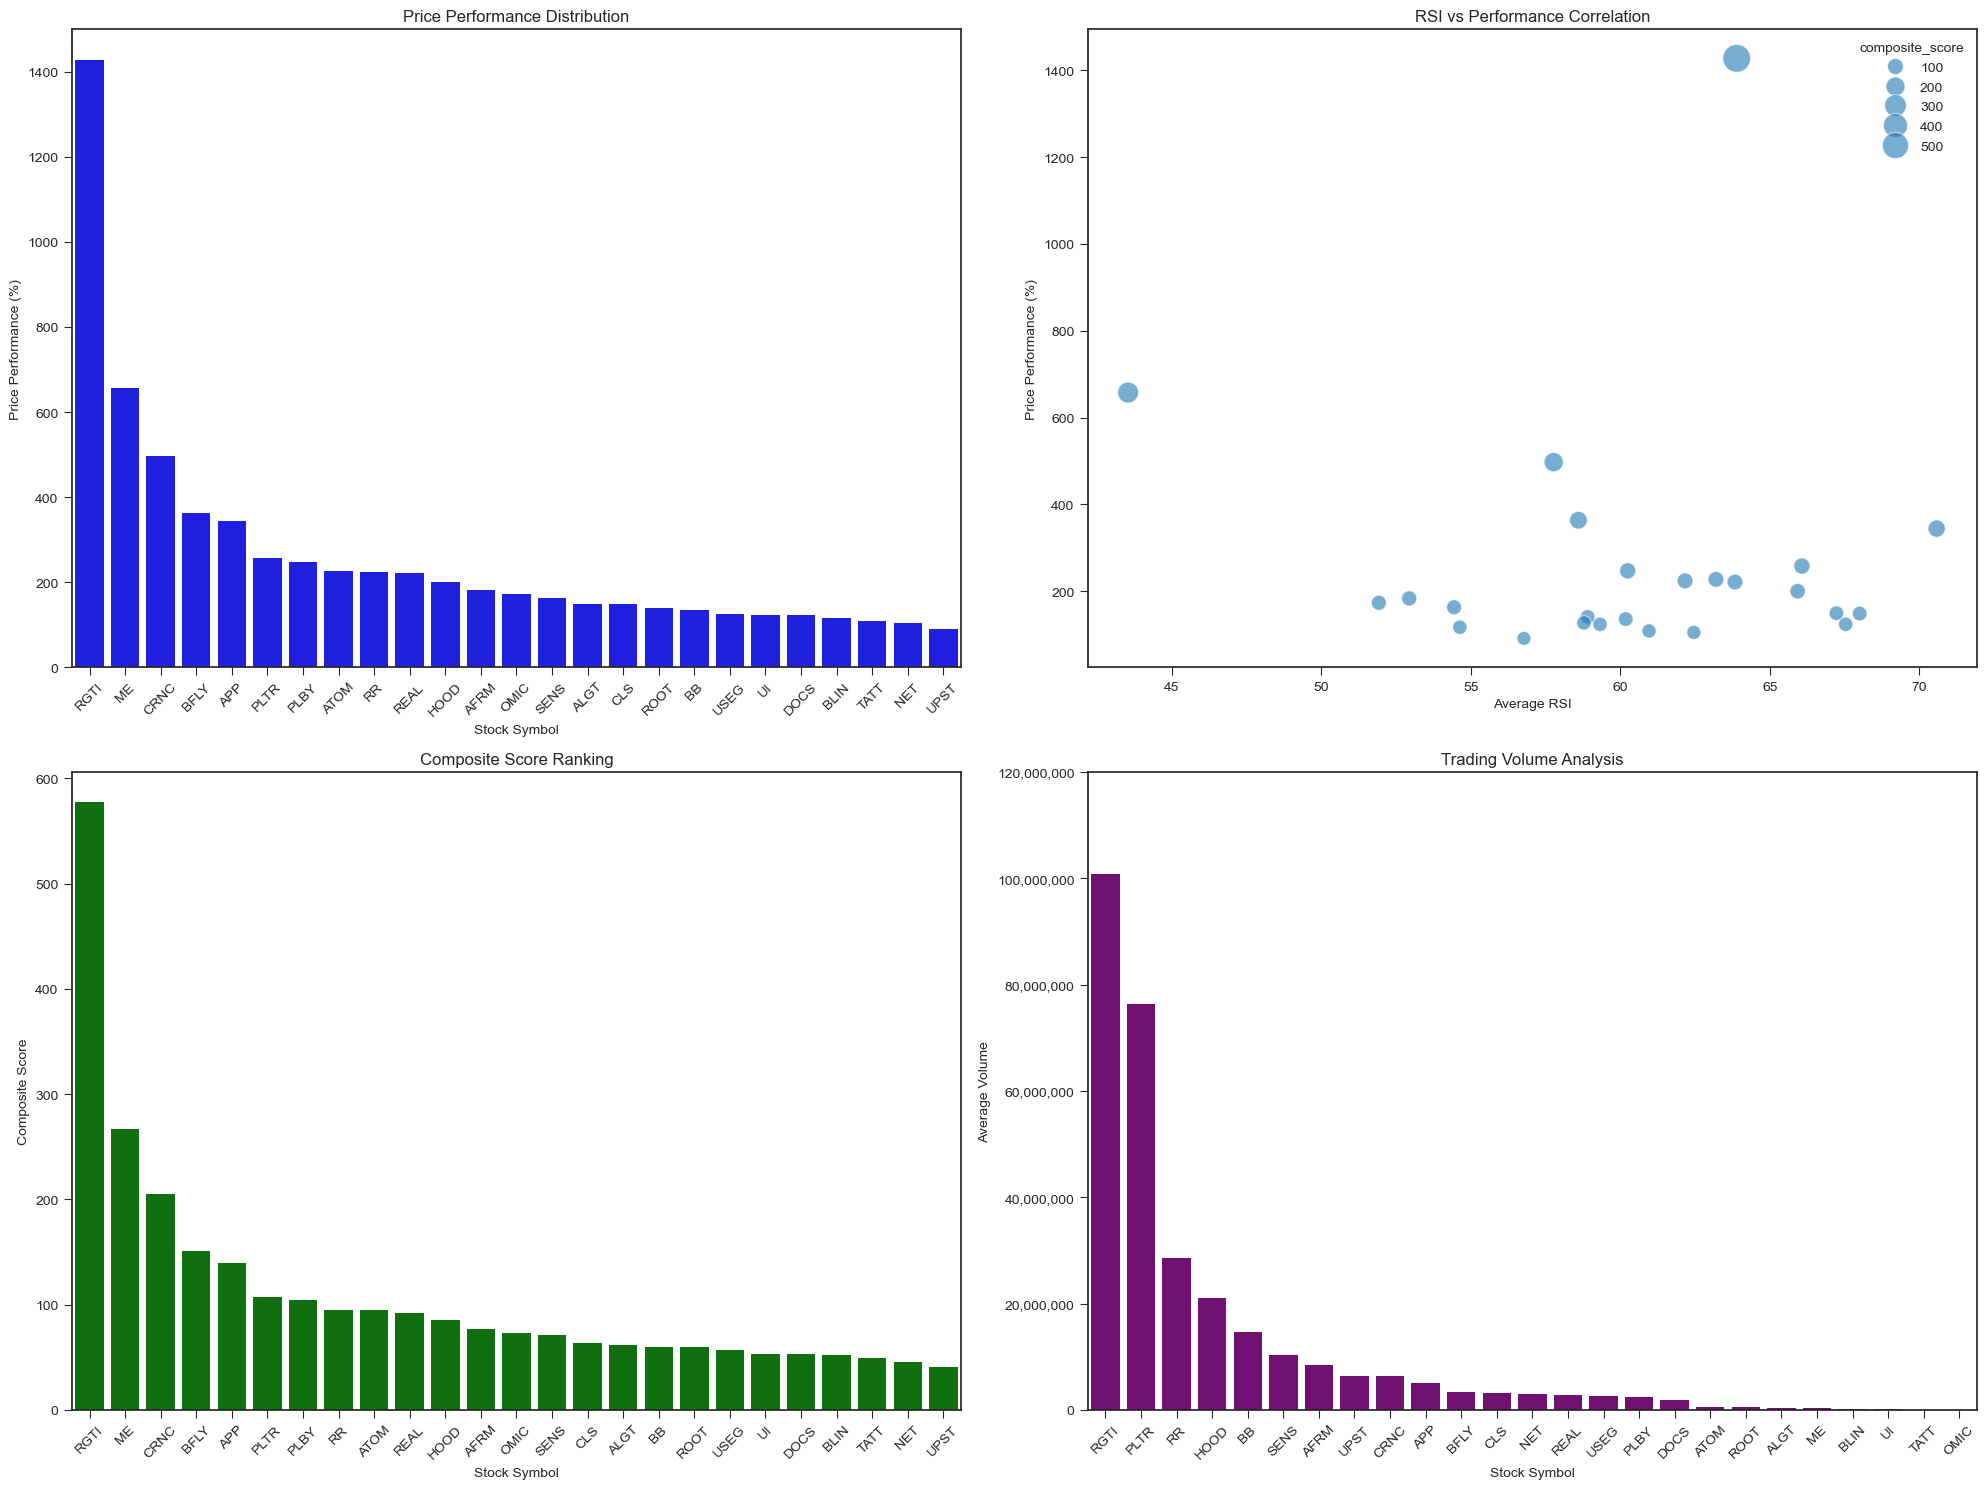

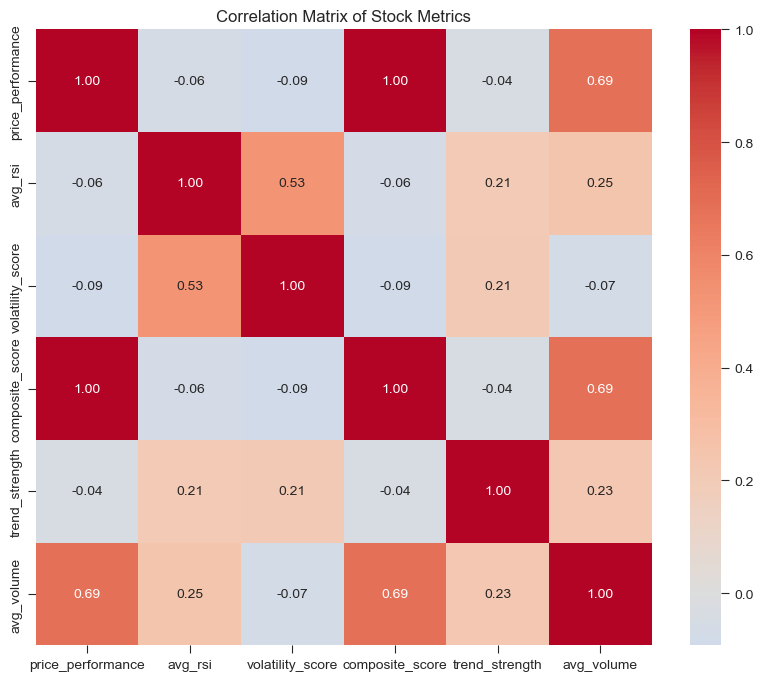

In [203]:
%matplotlib inline
# Create visualizations
dashboard, correlation = visualize_analysis(top_25_df)

# Display plots
dashboard.show()
correlation.show()

# Save plots if needed
#dashboard.savefig('stock_analysis_dashboard.png')
#correlation.savefig('correlation_matrix.png')